# Сжатие картинок с помощью SVD разложения
В этом задании нужно сделать сжатие изображения, сжатие с потерями. Для этого мы используем SVD разложение.

Примерный порядок действий:
1) Найти любую картинку,
2) Прочитать её с помощью библиотеки PIL
3) Преобразовать в numpy массив
4) Применить SVD к матрице - обязательно прочитайте справку по этой функции `np.linalg.svd`

**Примечание**: Цветная картинка представляет собой трёхканальное изображение RBG, поэтому напрямую SVD разложение применить не получится. Либо вы преобразуете изображение в одноканальное (градации серого), усредняя все три канала. Либо делаете SVD для всех трёх каналов в отдельности.

5) Далее оставляете небольшое количество сингулярных значений - 1, 2, 10, 30, 100. И выводите результат в виде получившейся картинки - чем больше сингулярных чисел, тем ближе приближённая матрица к исходной.

6) Сравните количество байт, необходимых для хранения исходной картинки и сжатой версии.

Ниже представлены основные функции и библиотеки, которые вам понадобятся.

Задание оформляете в виде блокнота jupyter. Особо понравившиеся картинки можно сохранить отдельно на диск, но мне удобнее чтобы они присутствовали в самом jupyter блокноте.

In [ ]:

import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display


from PIL import Image
import requests

response = requests.get("https://i.ytimg.com/vi/D7Dt0BRFO2w/maxresdefault.jpg", stream=True)
response.raw.decode_content = True
img = Image.open(response.raw)


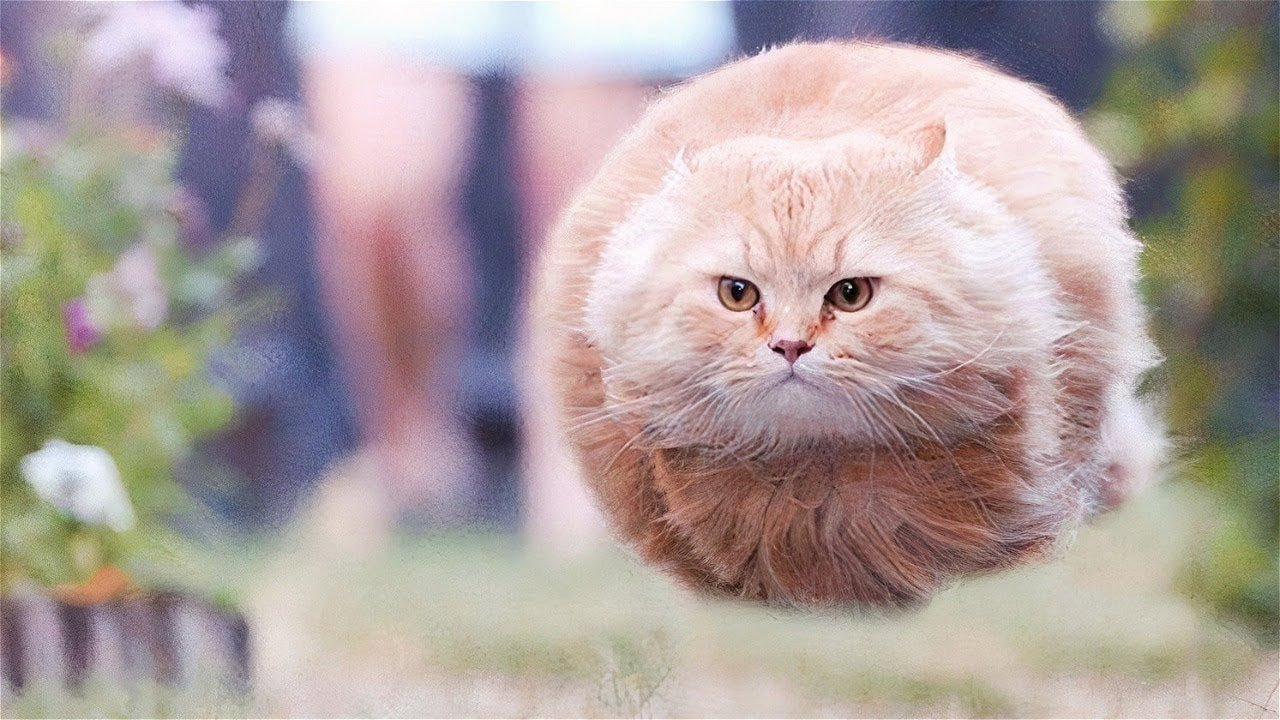

In [2]:
img

In [8]:
#разложение на цвета

x = np.array(img, dtype = np.float32)
red = x[:,:,0]
green = x[:,:,1]
blue = x[:,:,2]

shapeofx = x.shape

In [9]:
# эсведируем

U_red, S_red, V_red = np.linalg.svd(red, full_matrices = False)
U_green, S_green, V_green = np.linalg.svd(green, full_matrices = False)
U_blue, S_blue, V_blue = np.linalg.svd(blue, full_matrices = False)

print("количество сингулярных значений для красного цвета равно ", len(S_red))
print("количество сингулярных значений для зеленого цвета равно ", len(S_green))
print("количество сингулярных значений для голубого цвета равно ", len(S_blue))
print(x.shape)

количество сингулярных значений для красного цвета равно  720
количество сингулярных значений для зеленого цвета равно  720
количество сингулярных значений для голубого цвета равно  720
(720, 1280, 3)


In [10]:
for r in range (1, 130, 10):
    Y_r_red = U_red[:,:r].dot(np.diag(S_red[:r])).dot(V_red[:r,:]) 
    Y_r_red[Y_r_red < 0] = 0
    Y_r_red[Y_r_red > 255] = 255
    Y_r_red = Y_r_red.reshape(720, 1280, 1)
    Y_r_green = U_green[:,:r].dot(np.diag(S_green[:r])).dot(V_green[:r,:]) 
    Y_r_green[Y_r_green < 0] = 0
    Y_r_green[Y_r_green > 255] = 255
    Y_r_green = Y_r_green.reshape(720, 1280, 1)
    Y_r_blue = U_blue[:,:r].dot(np.diag(S_blue[:r])).dot(V_blue[:r,:]) 
    Y_r_blue[Y_r_blue < 0] = 0
    Y_r_blue[Y_r_blue > 255] = 255
    Y_r_blue = Y_r_blue.reshape(720, 1280, 1)
    Y_r = np.concatenate((np.concatenate((Y_r_red, Y_r_green), axis = 2), Y_r_blue), axis = 2)
    Image.fromarray(np.asarray(Y_r, dtype=np.uint8)).save(f'{r}.turbo_meow.jpg')

In [12]:
very_cursed = Image.open('11.turbo_meow.jpg')
very_cursed
img.save('720turbo_meow.jpg')

In [20]:
import os

print("Исходный файл:", os.path.getsize('720turbo_meow.jpg'), "\nСжатый до 130 синг.знач.: ", os.path.getsize('121.turbo_meow.jpg'), " В байтах")
print("размер одиннадцатого ", os.path.getsize('11.turbo_meow.jpg'))

Исходный файл: 166228 
Сжатый до 130 синг.знач.:  115497  В байтах
размер одиннадцатого  61641
